In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
#2 Load Data
df = pd.read_csv("gold_price.csv", parse_dates=True, index_col='Date')

In [4]:
df.head()

,USD (AM),USD (PM),GBP (AM),GBP (PM),EURO (AM),EURO (PM)
Date,,,,,,
2001-01-02,272.80,271.10,183.026,181.617,288.677,287.334
2001-01-03,269.00,267.15,178.916,177.390,281.823,281.655
2001-01-04,268.75,267.10,178.869,178.352,282.538,282.049
2001-01-05,268.00,267.40,178.488,178.148,280.775,280.882
2001-01-08,268.60,268.30,178.769,178.664,282.410,282.481


In [5]:
df.isnull().sum()

USD (AM)      0
USD (PM)     36
GBP (AM)      0
GBP (PM)     36
EURO (AM)     0
EURO (PM)    36
dtype: int64

In [6]:
df.value_counts()

USD (AM)  USD (PM)  GBP (AM)  GBP (PM)  EURO (AM)  EURO (PM)
1896.50   1895.00   1174.667  1178.922  1341.136   1345.594     1
256.70    257.45    176.572   177.063   281.531    280.967      1
257.00    257.10    180.414   180.295   290.461    290.246      1
257.05    256.65    178.050   177.674   286.982    286.920      1
257.30    257.50    178.124   178.225   280.895    281.729      1
                                                               ..
259.40    259.25    180.792   180.411   292.117    291.063      1
259.50    258.55    178.412   178.520   284.228    284.904      1
259.95    260.45    179.934   179.869   287.174    286.681      1
260.10    258.85    182.143   181.968   295.233    295.491      1
260.20    260.15    180.694   180.949   293.183    294.121      1
Name: count, Length: 4682, dtype: int64

In [7]:
#3 Feature Engineering
# We use 'USD (PM)' as our main price column
df['Return'] = df['USD (PM)'].pct_change() * 100
df['Lagged_Return'] = df['Return'].shift()

In [8]:
# 1. Moving Average of Returns (Trend)
df['SMA_3'] = df['Lagged_Return'].rolling(window=3).mean()
df['SMA_7'] = df['Lagged_Return'].rolling(window=7).mean()

# 2. Volatility (Risk) - Standard deviation of last 7 days
df['Volatility'] = df['Lagged_Return'].rolling(window=7).std()

# 3. Momentum - Difference between yesterday's return and 3 days ago
df['Momentum'] = df['Lagged_Return'] - df['Lagged_Return'].shift(3)

df = df.dropna()

In [9]:
#4 Train/Test Split
train = df.loc['2001':'2018']
test = df.loc['2019']

feature_cols = ['Lagged_Return', 'SMA_3', 'SMA_7', 'Volatility', 'Momentum']
X_train = train[feature_cols]
y_train = train['Return']
X_test = test[feature_cols]
y_test = test['Return']

In [10]:
# Model 1: Linear Regression (Baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Model 2: Random Forest (Advanced)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [11]:
#6 Evaluation
def print_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}\n")

print_metrics("Linear Regression", y_test, lr_pred)
print_metrics("Random Forest", y_test, rf_pred)

Linear Regression Performance:
RMSE: 0.7423
R2 Score: -0.0181

Random Forest Performance:
RMSE: 0.7920
R2 Score: -0.1590



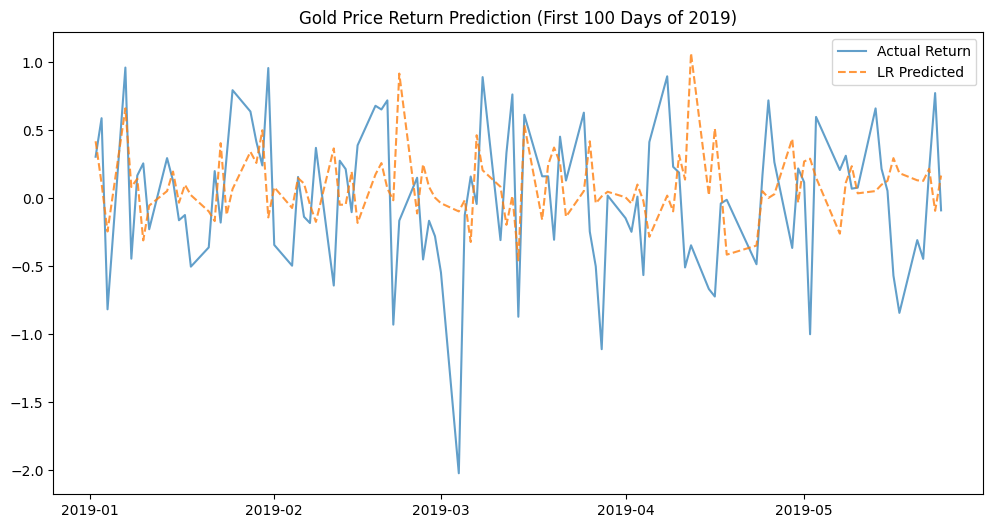

In [12]:
#7 Visualization (Actual vs Predicted)
plt.figure(figsize=(12, 6))
# Plotting only the first 100 days for clarity
plt.plot(y_test.index[:100], y_test.values[:100], label='Actual Return', alpha=0.7)
plt.plot(y_test.index[:100], rf_pred[:100], label='LR Predicted', linestyle='--', alpha=0.8)
plt.title('Gold Price Return Prediction (First 100 Days of 2019)')
plt.legend()
plt.show()

In [13]:
#8 The Backtesting Strategy
# Logic: If model predicts positive return, we Buy (Hold). If negative, we stay in Cash.
test['Predicted_Signal'] = np.where(lr_pred > 0, 1, 0)
test['Strategy_Return'] = test['Return'] * test['Predicted_Signal']

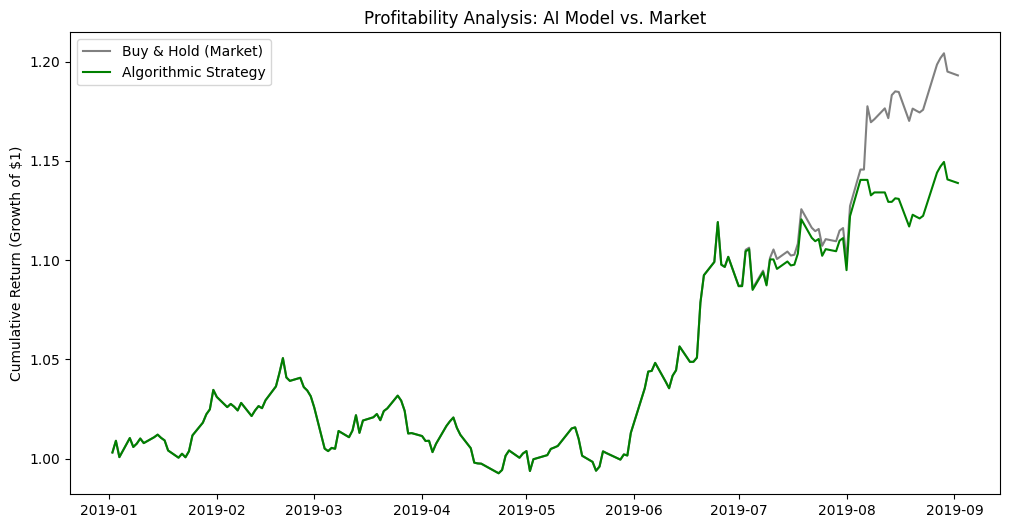

In [14]:
# Calculate Cumulative Returns
test['Cumulative_Market'] = (1 + test['Return'] / 100).cumprod()
test['Cumulative_Strategy'] = (1 + test['Strategy_Return'] / 100).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Cumulative_Market'], label='Buy & Hold (Market)', color='gray')
plt.plot(test.index, test['Cumulative_Strategy'], label='Algorithmic Strategy', color='green')
plt.title('Profitability Analysis: AI Model vs. Market')
plt.ylabel('Cumulative Return (Growth of $1)')
plt.legend()
plt.show()